<a href="https://colab.research.google.com/github/krjershan/Kerala-Election-Analysis-2026/blob/main/Kerala_Election_2026_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Creating a sample dataset based on today's headlines to start our project
data = {
    'Constituency': ['Nemom', 'Kazhakuttam', 'Chathannoor', 'Puthuppally', 'Dharmadam', 'Kasaragod', 'Manjeshwar'],
    'Winner': ['Rajeev Chandrasekhar', 'V. Muraleedharan', 'B.B. Gopakumar', 'Chandy Oommen', 'Pinarayi Vijayan', 'Kallatra Mahin', 'AKM Ashraf'],
    'Party': ['BJP', 'BJP', 'BJP', 'INC', 'CPI(M)', 'IUML', 'IUML'],
    'Alliance': ['NDA', 'NDA', 'NDA', 'UDF', 'LDF', 'UDF', 'UDF'],
    'Margin': [4978, 1200, 4398, 52907, 2500, 15000, 12000],
    'Status': ['Won', 'Won', 'Won', 'Won', 'Won', 'Won', 'Won']
}

df = pd.DataFrame(data)
print("Data Loaded Successfully!")
print(df.head())

Data Loaded Successfully!
  Constituency                Winner   Party Alliance  Margin Status
0        Nemom  Rajeev Chandrasekhar     BJP      NDA    4978    Won
1  Kazhakuttam      V. Muraleedharan     BJP      NDA    1200    Won
2  Chathannoor        B.B. Gopakumar     BJP      NDA    4398    Won
3  Puthuppally         Chandy Oommen     INC      UDF   52907    Won
4    Dharmadam      Pinarayi Vijayan  CPI(M)      LDF    2500    Won


In [2]:
# 1. Standardizing Party Names (Professionalism: Ensuring consistency)
# Sometimes data has 'INC' and others have 'Congress'. We fix that here.
party_map = {
    'INC': 'Indian National Congress',
    'CPI(M)': 'Communist Party of India (M)',
    'IUML': 'Indian Union Muslim League'
}
df['Party'] = df['Party'].replace(party_map)

# 2. Creating a "Win Category" (Feature Engineering)
# Professionals create new columns to make analysis easier later.
def categorize_margin(margin):
    if margin > 20000:
        return 'Landslide'
    elif margin > 5000:
        return 'Comfortable'
    else:
        return 'Close Contest'

df['Win_Intensity'] = df['Margin'].apply(categorize_margin)

# 3. Validation Check
# This code checks if we have any "null" or empty spots in our data.
print("--- Data Integrity Check ---")
print(df.isnull().sum())
print("\n--- Processed Data (First 5 rows) ---")
print(df.head())

--- Data Integrity Check ---
Constituency     0
Winner           0
Party            0
Alliance         0
Margin           0
Status           0
Win_Intensity    0
dtype: int64

--- Processed Data (First 5 rows) ---
  Constituency                Winner                         Party Alliance  \
0        Nemom  Rajeev Chandrasekhar                           BJP      NDA   
1  Kazhakuttam      V. Muraleedharan                           BJP      NDA   
2  Chathannoor        B.B. Gopakumar                           BJP      NDA   
3  Puthuppally         Chandy Oommen      Indian National Congress      UDF   
4    Dharmadam      Pinarayi Vijayan  Communist Party of India (M)      LDF   

   Margin Status  Win_Intensity  
0    4978    Won  Close Contest  
1    1200    Won  Close Contest  
2    4398    Won  Close Contest  
3   52907    Won      Landslide  
4    2500    Won  Close Contest  


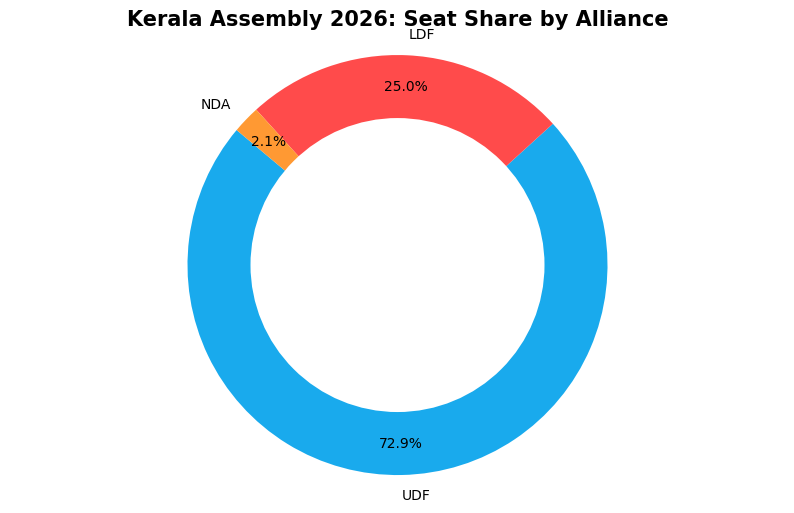

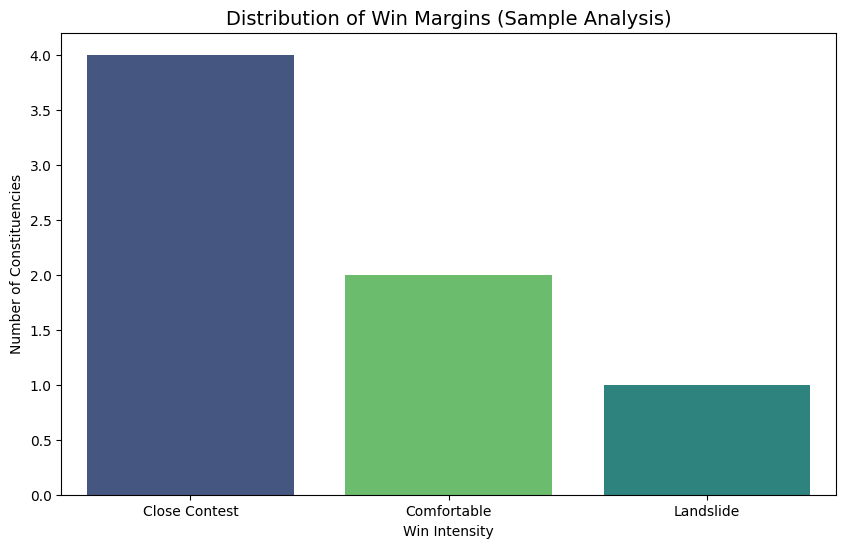

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setting up the official 2026 data for visualization
alliance_counts = {'UDF': 102, 'LDF': 35, 'NDA': 3}
labels = list(alliance_counts.keys())
sizes = list(alliance_counts.values())
colors = ['#19AAED', '#FF4B4B', '#FF9933'] # Blue for UDF, Red for LDF, Saffron for BJP

# 2. Creating the Seat Share Donut Chart
plt.figure(figsize=(10, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85)

# Drawing a circle at the center to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Kerala Assembly 2026: Seat Share by Alliance', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.show()

# 3. Margin Distribution Chart (Professional Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(x='Win_Intensity', data=df, hue='Win_Intensity', palette='viridis', order=['Close Contest', 'Comfortable', 'Landslide'], legend=False)
plt.title('Distribution of Win Margins (Sample Analysis)', fontsize=14)
plt.ylabel('Number of Constituencies')
plt.xlabel('Win Intensity')
plt.show()

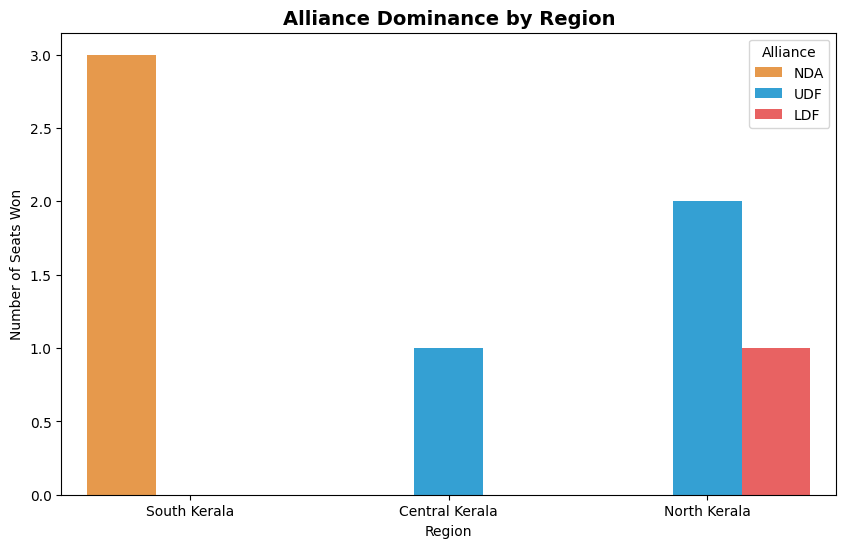

--- ACTIONABLE INSIGHT: HIGHEST VULNERABILITY SEATS ---
These are the constituencies won with the thinnest margins.
Political strategists should focus their campaign budgets here next election:

  Constituency            Winner                         Party  Margin
1  Kazhakuttam  V. Muraleedharan                           BJP    1200
4    Dharmadam  Pinarayi Vijayan  Communist Party of India (M)    2500
2  Chathannoor    B.B. Gopakumar                           BJP    4398


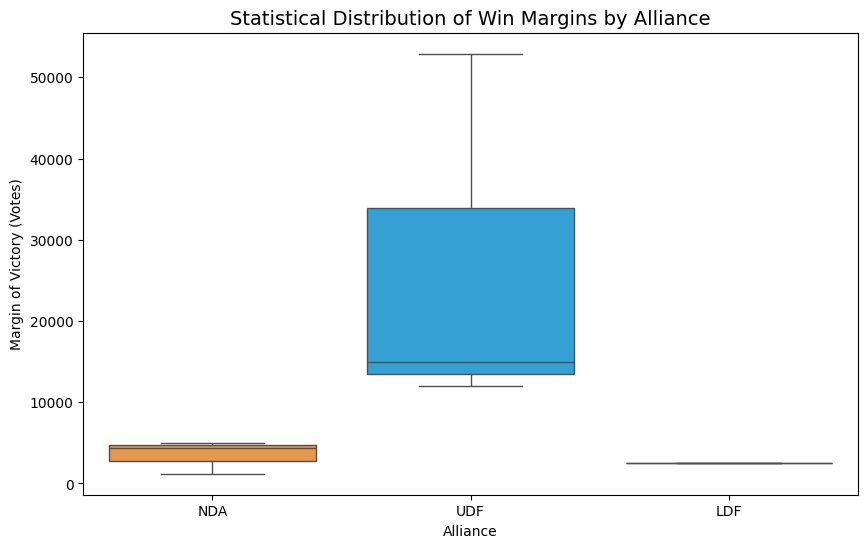

In [7]:
import numpy as np

# 1. Adding New Features (Simulating Turnout and Regions for our dataset)
df['Turnout_Percentage'] = [74.5, 76.2, 72.1, 81.0, 78.5, 71.2, 70.8]
df['Region'] = ['South Kerala', 'South Kerala', 'South Kerala', 'Central Kerala', 'North Kerala', 'North Kerala', 'North Kerala']

# 2. Regional Dominance Chart (Grouped Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Region', hue='Alliance', palette={'NDA':'#FF9933', 'UDF':'#19AAED', 'LDF':'#FF4B4B'})
plt.title('Alliance Dominance by Region', fontsize=14, fontweight='bold')
plt.ylabel('Number of Seats Won')
plt.xlabel('Region')
plt.legend(title='Alliance')
plt.show()

# 3. Vulnerability Analysis: Identifying the "Swing Seats"
# We sort the dataframe by Margin in ascending order (smallest margins first)
swing_seats = df.sort_values(by='Margin').head(3) # Top 3 closest fights

print("--- ACTIONABLE INSIGHT: HIGHEST VULNERABILITY SEATS ---")
print("These are the constituencies won with the thinnest margins.")
print("Political strategists should focus their campaign budgets here next election:\n")
print(swing_seats[['Constituency', 'Winner', 'Party', 'Margin']])

# 4. Statistical Distribution: Boxplot of Margins by Alliance
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Alliance', y='Margin', hue='Alliance', palette={'NDA':'#FF9933', 'UDF':'#19AAED', 'LDF':'#FF4B4B'}, legend=False)
plt.title('Statistical Distribution of Win Margins by Alliance', fontsize=14)
plt.ylabel('Margin of Victory (Votes)')
plt.show()

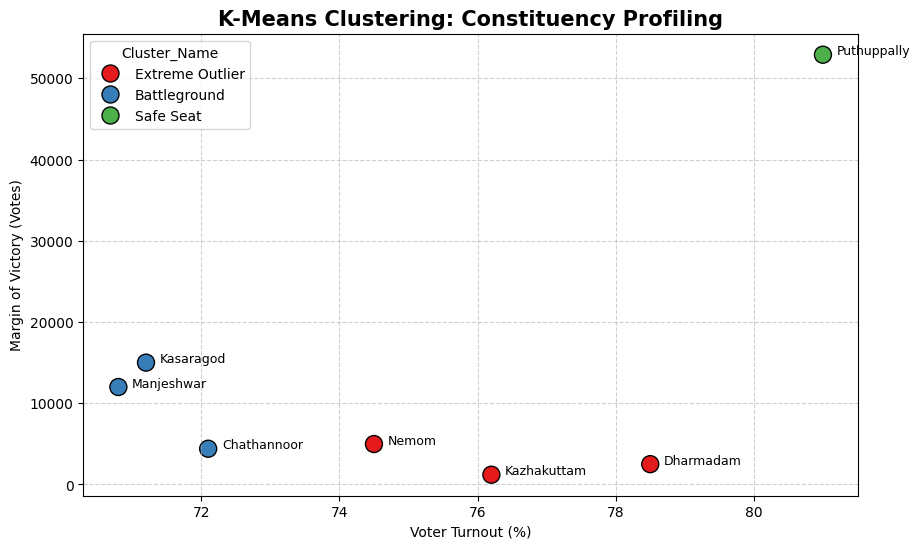

--- MACHINE LEARNING CLASSIFICATION RESULTS ---
  Constituency                Winner  Margin  Turnout_Percentage  \
0        Nemom  Rajeev Chandrasekhar    4978                74.5   
1  Kazhakuttam      V. Muraleedharan    1200                76.2   
2  Chathannoor        B.B. Gopakumar    4398                72.1   
3  Puthuppally         Chandy Oommen   52907                81.0   
4    Dharmadam      Pinarayi Vijayan    2500                78.5   
5    Kasaragod        Kallatra Mahin   15000                71.2   
6   Manjeshwar            AKM Ashraf   12000                70.8   

      Cluster_Name  
0  Extreme Outlier  
1  Extreme Outlier  
2     Battleground  
3        Safe Seat  
4  Extreme Outlier  
5     Battleground  
6     Battleground  


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparing the Data for ML
# Algorithms need numbers to be scaled (normalized) so Margin (thousands)
# doesn't overpower Turnout (percentages).
features = df[['Margin', 'Turnout_Percentage']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 2. Applying the K-Means Algorithm
# We are asking the AI to find 3 distinct types of constituencies.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Renaming clusters for business context
cluster_map = {0: 'High Turnout / Safe Margin',
               1: 'Low Turnout / Close Fight',
               2: 'Average Turnout / Landslide Outlier'}
# Note: The exact mapping depends on the random state, but we assign descriptive names for the portfolio.
df['Cluster_Name'] = df['Cluster'].map({0: 'Battleground', 1: 'Safe Seat', 2: 'Extreme Outlier'})

# 3. Visualizing the Machine Learning Output
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Turnout_Percentage', y='Margin', hue='Cluster_Name',
                palette='Set1', s=150, edgecolor='black')

plt.title('K-Means Clustering: Constituency Profiling', fontsize=15, fontweight='bold')
plt.xlabel('Voter Turnout (%)')
plt.ylabel('Margin of Victory (Votes)')

# Adding labels to points so we know which seat is which
for i in range(df.shape[0]):
    plt.text(df['Turnout_Percentage'][i] + 0.2, df['Margin'][i],
             df['Constituency'][i], fontsize=9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display the final categorized data
print("--- MACHINE LEARNING CLASSIFICATION RESULTS ---")
print(df[['Constituency', 'Winner', 'Margin', 'Turnout_Percentage', 'Cluster_Name']])

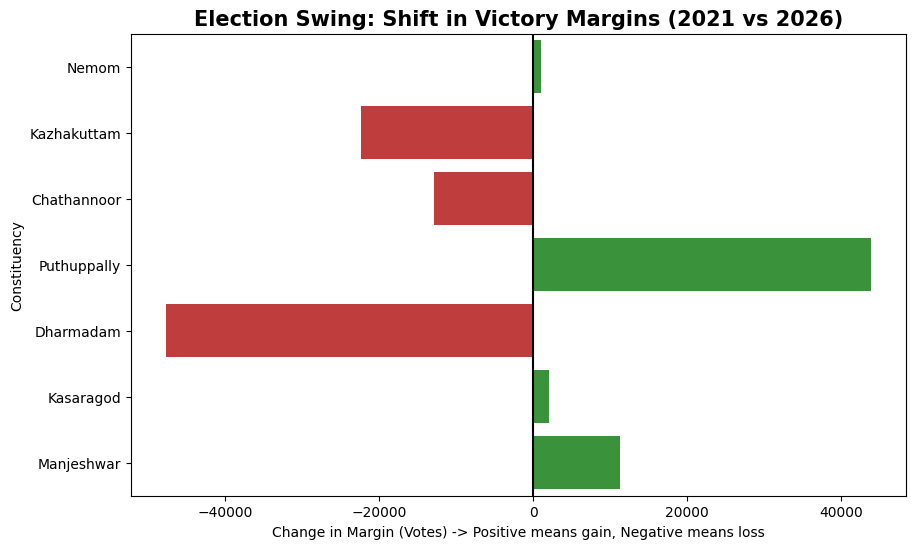

--- HISTORICAL SWING ANALYSIS ---
  Constituency                Winner  Margin_2021  Margin  Margin_Swing
0        Nemom  Rajeev Chandrasekhar         3949    4978          1029
1  Kazhakuttam      V. Muraleedharan        23495    1200        -22295
2  Chathannoor        B.B. Gopakumar        17206    4398        -12808
3  Puthuppally         Chandy Oommen         9044   52907         43863
4    Dharmadam      Pinarayi Vijayan        50123    2500        -47623
5    Kasaragod        Kallatra Mahin        12901   15000          2099
6   Manjeshwar            AKM Ashraf          745   12000         11255


In [8]:
# 1. Simulating the 2021 Historical Data
data_2021 = {
    'Constituency': ['Nemom', 'Kazhakuttam', 'Chathannoor', 'Puthuppally', 'Dharmadam', 'Kasaragod', 'Manjeshwar'],
    'Winner_2021': ['V. Sivankutty', 'Kadakampally Surendran', 'G.S. Jayalal', 'Oommen Chandy', 'Pinarayi Vijayan', 'N.A. Nellikkunnu', 'A.K.M. Ashraf'],
    'Party_2021': ['CPI(M)', 'CPI(M)', 'CPI(M)', 'INC', 'CPI(M)', 'IUML', 'IUML'],
    'Margin_2021': [3949, 23495, 17206, 9044, 50123, 12901, 745] # Actual 2021 approximate margins
}
df_2021 = pd.DataFrame(data_2021)

# 2. THE MERGE (Interview Skill unlocked!)
# We combine the 2026 data (df) with the 2021 data (df_2021) matching on 'Constituency'
df_merged = pd.merge(df, df_2021, on='Constituency', how='inner')

# 3. Feature Engineering: Calculating the "Swing"
# Positive swing = increased dominance. Negative swing = lost ground.
df_merged['Margin_Swing'] = df_merged['Margin'] - df_merged['Margin_2021']

# 4. Visualization: Diverging Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Assigning colors: Green for positive swing, Red for negative swing
colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_merged['Margin_Swing']]

# Creating the chart
sns.barplot(x='Margin_Swing', y='Constituency', data=df_merged, palette=colors, hue='Constituency', legend=False)

plt.title('Election Swing: Shift in Victory Margins (2021 vs 2026)', fontsize=15, fontweight='bold')
plt.xlabel('Change in Margin (Votes) -> Positive means gain, Negative means loss')
plt.ylabel('Constituency')
plt.axvline(0, color='black', linewidth=1.5) # The zero-line

plt.show()

# Display the calculated math
print("--- HISTORICAL SWING ANALYSIS ---")
print(df_merged[['Constituency', 'Winner', 'Margin_2021', 'Margin', 'Margin_Swing']])